In [1]:
import numpy as np

num_simulations = 1000

noise_values = np.random.uniform(0,10,num_simulations)
sample_sizes = np.random.randint(100,500,num_simulations)

In [2]:
from sklearn.datasets import make_regression
import pandas as pd

all_data = []

for i in range(num_simulations):
    X, y = make_regression(
        n_samples=sample_sizes[i],
        n_features=5,
        noise=noise_values[i],
        random_state=i
    )

    df = pd.DataFrame(X)
    df["target"] = y
    all_data.append(df)

dataset = pd.concat(all_data)
dataset.head()

,0,1,2,3,4,target
0,1.929532,-0.498032,-1.225436,0.087551,0.949421,14.106022
1,-0.470033,0.379236,-0.178589,-0.930157,-0.216731,-53.413712
2,0.923797,0.460814,-1.998639,-0.289005,-0.132568,-125.504857
3,-0.813596,0.625119,-1.297380,-0.073120,-0.521642,-137.516683
4,-0.369801,0.239583,0.406415,2.133868,0.972536,227.053121


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X = dataset.drop("target",axis=1)
y = dataset["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results[name] = mse

results

{'Linear Regression': 4278.982670894118,
 'Ridge Regression': 4278.982509009018,
 'Lasso Regression': 4283.157388377965,
 'Decision Tree': 9066.200717198772,
 'Random Forest': 4635.482823964262,
 'Gradient Boosting': 4413.580227145804,
 'SVR': 4527.586635266465,
 'KNN': 5193.115373942211}

In [5]:
import pandas as pd

result_df = pd.DataFrame(
    results.items(),
    columns=["Model","MSE"]
).sort_values(by="MSE")

result_df

,Model,MSE
1,Ridge Regression,4278.982509
0,Linear Regression,4278.982671
2,Lasso Regression,4283.157388
5,Gradient Boosting,4413.580227
6,SVR,4527.586635
4,Random Forest,4635.482824
7,KNN,5193.115374
3,Decision Tree,9066.200717


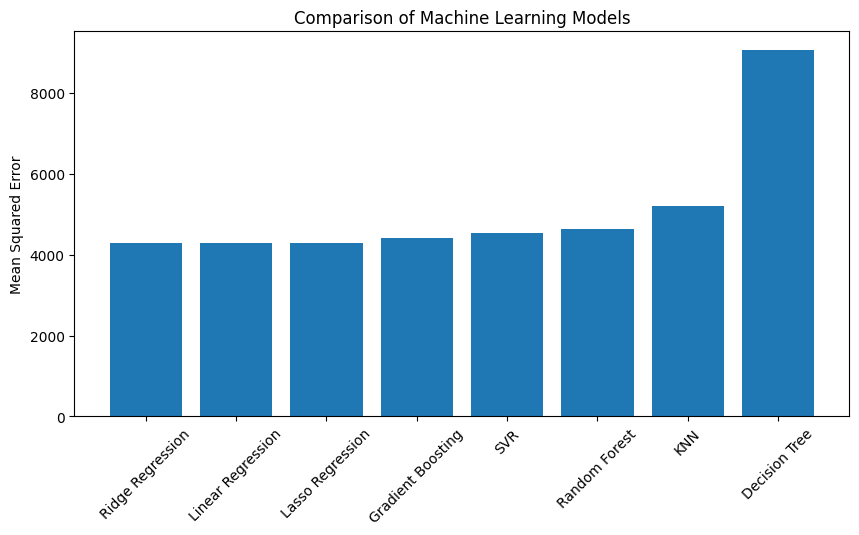

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(result_df["Model"], result_df["MSE"])
plt.xticks(rotation=45)
plt.ylabel("Mean Squared Error")
plt.title("Comparison of Machine Learning Models")
plt.show()